In [1]:
# Use num_env or mend_env
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import gc
from data_utilities import clean_dir_from_blanks, process_data

In [2]:
from plot_temuujin_df import plot_mean_df_scatter, plot_mean_df, return_random_samples, take_n_random_samples

In [2]:
# Import data from Results_altum_september

In [3]:
bad_altum_september = pd.read_csv('./Results_Altum_September/CSV/bad_10_data.csv')
good_altum_september = pd.read_csv('./Results_Altum_September/CSV/good_10_data.csv')
best_altum_september = pd.read_csv('./Results_Altum_September/CSV/best_10_data.csv')
medium_altum_september = pd.read_csv('./Results_Altum_September/CSV/medium_10_data.csv')
worst_altum_september = pd.read_csv('./Results_Altum_September/Worst_Only_run_3/Gabor_Results/CSV/worst_sep_altum_ortho_3.csv')

In [4]:
worst_altum_september

,Unnamed: 0,patch,start_vert,end_vert,start_horiz,end_horiz,Patch_Area,VegetationIndex,VI_Thresh,VI_Area,Pure_GaborArea,Pure_GaborThresh,LocalHistEq_GaborArea,LocalHistEq_GaborThresh
0,0,patch_1_4,256,512,1024,1280,65535,MSAVI,-0.246094,40741,NaN,NaN,NaN,NaN
1,0,patch_1_4,256,512,1024,1280,65535,NDVI,-0.996094,24795,10734.0,1.0,13337.0,0.019604
2,0,patch_1_5,256,512,1280,1536,65535,MSAVI,-0.316406,44965,NaN,NaN,NaN,NaN
3,0,patch_1_5,256,512,1280,1536,65535,NDVI,-0.996094,20571,4383.0,1.0,6565.0,0.022756
4,0,patch_1_6,256,512,1536,1792,65535,MSAVI,-0.316406,41869,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3879,0,patch_46_54,11776,12032,13824,14080,65535,NDVI,-0.996094,21485,8575.0,1.0,13114.0,0.023292
3880,0,patch_46_55,11776,12032,14080,14336,65535,MSAVI,-0.230469,45557,NaN,NaN,NaN,NaN
3881,0,patch_46_55,11776,12032,14080,14336,65535,NDVI,-0.996094,19979,9455.0,1.0,12768.0,0.025182
3882,0,patch_46_56,11776,12032,14336,14592,65535,MSAVI,-0.175781,38342,NaN,NaN,NaN,NaN


In [6]:
def split_by_vi_threshold(df):
    zeros = df[df['VI_Thresh'] == 0]
    nonzeros = df[df['VI_Thresh'] != 0]
    return zeros, nonzeros

def find_target_zeros(df):
    zeros = df
    zeros = zeros.loc[1::2]
    zeros = zeros[['patch', 'start_vert', 'end_vert', 'start_horiz', 'end_horiz']]
    return zeros
# Split best_altum_september
best_altum_september_zeros, best_altum_september_nonzeros = split_by_vi_threshold(best_altum_september)

# Split good_altum_september
good_altum_september_zeros, good_altum_september_nonzeros = split_by_vi_threshold(good_altum_september)

# Split medium_altum_september
medium_altum_september_zeros, medium_altum_september_nonzeros = split_by_vi_threshold(medium_altum_september)

# Split bad_altum_september
bad_altum_september_zeros, bad_altum_september_nonzeros = split_by_vi_threshold(bad_altum_september)

# Split worse_altum_september
worst_altum_september_zeros, worst_altum_september_nonzeros = split_by_vi_threshold(worst_altum_september)

In [7]:
gabor_dir = './Results_Altum_September/CSV/Gabor_Results/'
clean_dir_from_blanks(gabor_dir, worst_altum_september_zeros)

Targets found: 0
Targets found: 0
Targets found: 0
Targets found: 0
Finished job.


In [8]:
bad_altum_september_processed = process_data(bad_altum_september_nonzeros, 'bad')
good_altum_september_processed = process_data(good_altum_september_nonzeros, 'good')
best_altum_september_processed = process_data(best_altum_september_nonzeros, 'best')
medium_altum_september_processed = process_data(medium_altum_september_nonzeros, 'medium')
worst_altum_september_processed = process_data(worst_altum_september_nonzeros, 'worst')

In [9]:
worst_altum_september_processed

,patch_number,VegetationIndex,Patch_Area,VI_Area,Pure_GaborArea,AreaSum,Unknown_Area,class,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area
0,256_512_1024_1280,MSAVI,65535,40741,10734.0,51475.0,14060.0,worst,0.621668,0.163790,0.214542
1,256_512_1280_1536,MSAVI,65535,44965,4383.0,49348.0,16187.0,worst,0.686122,0.066880,0.246998
2,256_512_1536_1792,MSAVI,65535,41869,9676.0,51545.0,13990.0,worst,0.638880,0.147646,0.213474
3,256_512_1792_2048,MSAVI,65535,38263,119.0,38382.0,27153.0,worst,0.583856,0.001816,0.414328
4,256_512_2048_2304,MSAVI,65535,38105,14115.0,52220.0,13315.0,worst,0.581445,0.215381,0.203174
...,...,...,...,...,...,...,...,...,...,...,...
1937,11776_12032_13312_13568,MSAVI,65535,46095,11759.0,57854.0,7681.0,worst,0.703365,0.179431,0.117205
1938,11776_12032_13568_13824,MSAVI,65535,38555,0.0,38555.0,26980.0,worst,0.588312,0.000000,0.411688
1939,11776_12032_13824_14080,MSAVI,65535,44051,8575.0,52626.0,12909.0,worst,0.672175,0.130846,0.196979
1940,11776_12032_14080_14336,MSAVI,65535,45557,9455.0,55012.0,10523.0,worst,0.695155,0.144274,0.160571


In [11]:
area_df_altum_september = pd.concat([best_altum_september_processed, good_altum_september_processed, 
                                     medium_altum_september_processed, bad_altum_september_processed, worst_altum_september_processed], axis=0, ignore_index=True)

In [12]:
area_df_altum_september

,patch_number,VegetationIndex,Patch_Area,VI_Area,Pure_GaborArea,AreaSum,Unknown_Area,class,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area
0,0_256_768_1024,MSAVI,65535,36228,8149.0,44377.0,21158.0,best,0.552804,0.124346,0.322850
1,0_256_1792_2048,MSAVI,65535,36860,15921.0,52781.0,12754.0,best,0.562448,0.242939,0.194614
2,256_512_768_1024,MSAVI,65535,40506,14272.0,54778.0,10757.0,best,0.618082,0.217777,0.164141
3,256_512_1024_1280,MSAVI,65535,37875,8820.0,46695.0,18840.0,best,0.577935,0.134585,0.287480
4,256_512_1280_1536,MSAVI,65535,34705,4051.0,38756.0,26779.0,best,0.529564,0.061814,0.408621
...,...,...,...,...,...,...,...,...,...,...,...
9035,11776_12032_13312_13568,MSAVI,65535,46095,11759.0,57854.0,7681.0,worst,0.703365,0.179431,0.117205
9036,11776_12032_13568_13824,MSAVI,65535,38555,0.0,38555.0,26980.0,worst,0.588312,0.000000,0.411688
9037,11776_12032_13824_14080,MSAVI,65535,44051,8575.0,52626.0,12909.0,worst,0.672175,0.130846,0.196979
9038,11776_12032_14080_14336,MSAVI,65535,45557,9455.0,55012.0,10523.0,worst,0.695155,0.144274,0.160571


In [13]:
area_df_altum_september.groupby('class').count()

,patch_number,VegetationIndex,Patch_Area,VI_Area,Pure_GaborArea,AreaSum,Unknown_Area,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area
class,,,,,,,,,,
bad,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989
best,1516,1516,1516,1516,1516,1516,1516,1516,1516,1516
good,1641,1641,1641,1641,1641,1641,1641,1641,1641,1641
medium,1952,1952,1952,1952,1952,1952,1952,1952,1952,1952
worst,1942,1942,1942,1942,1942,1942,1942,1942,1942,1942


In [14]:
area_df_altum_september.to_csv('./Results_Altum_September/CSV/area_df_altum_september.csv', index=False)

In [3]:
area_df_altum_september = pd.read_csv('./Results_Altum_September/CSV/area_df_altum_september.csv')

100%|██████████| 5/5 [00:11<00:00,  2.22s/it]


{'Cworst,600,300': (127, 0, 0), 'Cworst,200,300': (190, 63, 63), 'Cworst,50,300': (253, 126, 126), 'Cbad,600,300': (0, 0, 127), 'Cbad,200,300': (63, 63, 190), 'Cbad,50,300': (126, 126, 253), 'Cmedium,600,300': (127, 127, 0), 'Cmedium,200,300': (190, 190, 63), 'Cmedium,50,300': (253, 253, 126), 'Cbest,600,300': (0, 127, 0), 'Cbest,200,300': (63, 190, 63), 'Cbest,50,300': (126, 253, 126), 'Cgood,600,300': (31, 31, 31), 'Cgood,200,300': (94, 94, 94), 'Cgood,50,300': (157, 157, 157)}


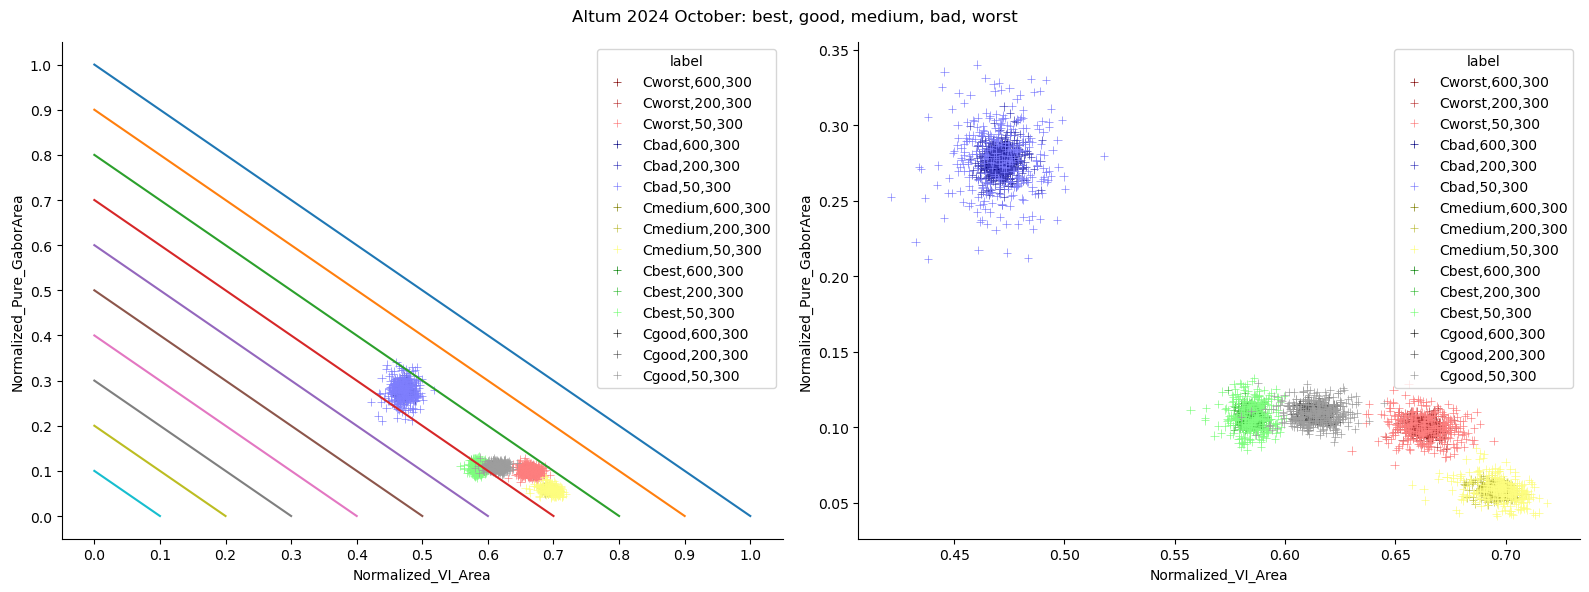

In [15]:
# 5 area plot
mean_df_altum_october, colors_normalized = return_random_samples(area_df_altum_september,  'Normalized_VI_Area', 'Normalized_Pure_GaborArea', 
                                target_classes = ['worst','bad','medium', 'best', 'good'],
                                all_N = [300]*5, 
                                all_sample_sizes = [600, 200, 50])
plot_mean_df_scatter(mean_df_altum_october,  'Normalized_VI_Area', 'Normalized_Pure_GaborArea', colors_normalized, 'label', 
                     title = 'Altum 2024 October: best, good, medium, bad, worst')

In [15]:
averages_altum_september = area_df_altum_september.groupby('class')[['VI_Area','Pure_GaborArea','AreaSum',
                                                         'Unknown_Area','Normalized_VI_Area',
                                                         'Normalized_Pure_GaborArea',
                                                         'Normalized_Unknown_Area']].mean(
                                                             numeric_only=True).reset_index()

In [16]:
averages_altum_october = pd.read_csv('./Processed_datas_October/averages_altum_october.csv')
averages_altum_october['Month'] = 'October'
averages_altum_september['Month'] = 'September'

In [17]:
averages_altum_september

,class,VI_Area,Pure_GaborArea,AreaSum,Unknown_Area,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area,Month
0,bad,30866.725993,18117.095525,48983.821518,16550.880845,0.470997,0.276450,0.252553,September
1,best,38294.523087,6998.672164,45293.195251,20241.699868,0.584337,0.106793,0.308870,September
2,good,40218.264473,7183.151737,47401.416210,18133.291895,0.613691,0.109608,0.276700,September
3,medium,45559.900615,3808.728484,49368.629098,16165.732070,0.695200,0.058118,0.246683,September
4,worst,43483.917096,6561.937693,50045.854789,15488.712667,0.663522,0.100129,0.236348,September


In [19]:
averages_altum_september.to_csv('./Processed_datas_September/averages_altum_september.csv', index=False)

In [26]:
combined_df = pd.concat([averages_altum_october, averages_altum_september], axis=0, ignore_index=True)

In [34]:
altum_sep_and_oct_mean = combined_df.groupby('class')[['Normalized_VI_Area', 'Normalized_Pure_GaborArea', 'Normalized_Unknown_Area']].mean(
    ).sort_values(by='Normalized_Unknown_Area', ascending=False)

In [35]:
altum_sep_and_oct_mean

,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area
class,,,
best,0.609563,0.067741,0.322696
bad,0.545861,0.181578,0.272561
good,0.646586,0.083297,0.270117
medium,0.702504,0.052448,0.245048
worst,0.704412,0.096796,0.198792


In [ ]:
combined_df

,class,VI_Area,Pure_GaborArea,AreaSum,Unknown_Area,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area,Month
0,bad,40679.092253,5682.222222,46361.314475,19173.233945,0.620725,0.086706,0.292570,October
1,best,41600.865445,1880.133923,43480.999368,22053.819962,0.634789,0.028689,0.336522,October
2,good,44529.736820,3734.537657,48264.274477,17270.381590,0.679480,0.056986,0.263534,October
3,medium,46517.235718,3065.642343,49582.878060,15951.607777,0.709808,0.046779,0.243413,October
4,worst,48843.383434,6125.019079,54968.402513,10566.507213,0.745302,0.093462,0.161236,October
5,bad,30866.725993,18117.095525,48983.821518,16550.880845,0.470997,0.276450,0.252553,September
6,best,38294.523087,6998.672164,45293.195251,20241.699868,0.584337,0.106793,0.308870,September
7,good,40218.264473,7183.151737,47401.416210,18133.291895,0.613691,0.109608,0.276700,September
8,medium,45559.900615,3808.728484,49368.629098,16165.732070,0.695200,0.058118,0.246683,September
9,worst,43483.917096,6561.937693,50045.854789,15488.712667,0.663522,0.100129,0.236348,September
